# What Factors Influence Whether a Shipment is Delayed or Not?

### Author
Imran Qureshi

### Notebook Overview
This notebook focuses specifically on predicting whether a shipment will be delivered late or on time using classification-based analytical techniques in R. The analysis evaluates operational, transportation-related, route-related, and disruption-related variables associated with shipment delay outcomes.


# Exploratory Data Analysis (EDA)

Initial exploratory data analysis was performed to better understand the distributions and variation of shipment-related variables before classification modeling. Histograms and summary statistics were used to evaluate patterns associated with delayed and on-time deliveries.


'data.frame':	10000 obs. of  19 variables:
 $ Order_Date              : chr  "1/4/2024" "1/4/2024" "1/4/2024" "1/4/2024" ...
 $ Origin_City             : chr  "Tokyo, JP" "Shanghai, CN" "Santos, BR" "Tokyo, JP" ...
 $ Destination_City        : chr  "Singapore, SG" "Los Angeles, US" "Shanghai, CN" "Singapore, SG" ...
 $ Route_Type              : chr  "Intra-Asia" "Pacific" "Commodity" "Intra-Asia" ...
 $ Transportation_Mode     : chr  "Sea" "Sea" "Sea" "Sea" ...
 $ Product_Category        : chr  "Perishable Foods" "Textiles" "Consumer Electronics" "Perishable Foods" ...
 $ Base_Lead_Time_Days     : int  7 18 35 7 7 28 24 35 7 12 ...
 $ Scheduled_Lead_Time_Days: int  10 19 38 8 10 31 27 37 9 15 ...
 $ Actual_Lead_Time_Days   : int  10 18 35 7 7 27 24 35 7 12 ...
 $ Delay_Days              : int  0 -1 -3 -1 -3 -4 -3 -2 -2 -3 ...
 $ Delivery_Status         : chr  "On Time" "On Time" "On Time" "On Time" ...
 $ Disruption_Event        : chr  "Port Congestion" "None" "None" "None" ...
 $ Geop

   Order_Date         Origin_City        Destination_City        Route_Type  
 Min.   :2024-01-04   Length:10000       Length:10000       Atlantic  :1701  
 1st Qu.:2024-07-01   Class :character   Class :character   Commodity :1608  
 Median :2024-12-27   Mode  :character   Mode  :character   Intra-Asia:1634  
 Mean   :2024-12-29                                         Pacific   :1645  
 3rd Qu.:2025-07-01                                         Suez      :3412  
 Max.   :2026-01-03                                                          
                                                                             
 Transportation_Mode             Product_Category Base_Lead_Time_Days
 Air:1729            Auto Parts          :1416    Min.   : 2.00      
 Sea:8271            Consumer Electronics:1458    1st Qu.: 7.00      
                     Perishable Foods    :1402    Median :18.00      
                     Pharmaceuticals     :1432    Mean   :17.51      
                     Raw M

,skim_type,skim_variable,n_missing,complete_rate,Date.min,Date.max,Date.median,Date.n_unique,character.min,character.max,⋯,factor.n_unique,factor.top_counts,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<date>,<date>,<date>,<int>,<int>,<int>,⋯,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,Date,Order_Date,0,1,2024-01-04,2026-01-03,2024-12-27,731,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,character,Origin_City,0,1,NA,NA,NA,NA,9,12,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,character,Destination_City,0,1,NA,NA,NA,NA,12,15,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,character,Disruption_Event,0,1,NA,NA,NA,NA,4,39,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,character,Cost..USD....per.Kg,0,1,NA,NA,NA,NA,5,6,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6,character,Mitigation_Action_Taken,0,1,NA,NA,NA,NA,10,21,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
7,factor,Route_Type,0,1,NA,NA,NA,NA,NA,NA,⋯,5,"Sue: 3412, Atl: 1701, Pac: 1645, Int: 1634",NA,NA,NA,NA,NA,NA,NA,NA
8,factor,Transportation_Mode,0,1,NA,NA,NA,NA,NA,NA,⋯,2,"Sea: 8271, Air: 1729",NA,NA,NA,NA,NA,NA,NA,NA
9,factor,Product_Category,0,1,NA,NA,NA,NA,NA,NA,⋯,7,"Con: 1458, Sem: 1454, Tex: 1440, Pha: 1432",NA,NA,NA,NA,NA,NA,NA,NA


Warning message in FUN(newX[, i], ...):
"no non-missing arguments to min; returning Inf"
Warning message in FUN(newX[, i], ...):
"no non-missing arguments to max; returning -Inf"


,vars,n,mean,sd,median,trimmed,mad,min,max,range,skew,kurtosis,se
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Order_Date,1,10000,NaN,NA,NA,NaN,NA,Inf,-Inf,-Inf,NA,NA,NA
Origin_City*,2,10000,3.48390,1.712727e+00,3.00,3.479875,2.965200,1.00,6.00,5.00,0.006916537,-1.28325223,1.712727e-02
Destination_City*,3,10000,3.47550,1.704902e+00,3.00,3.469375,1.482600,1.00,6.00,5.00,0.016629616,-1.25677934,1.704902e-02
Route_Type*,4,10000,3.34590,1.500359e+00,4.00,3.432375,1.482600,1.00,5.00,4.00,-0.297444281,-1.36879359,1.500359e-02
Transportation_Mode*,5,10000,1.82710,3.781797e-01,2.00,1.908875,0.000000,1.00,2.00,1.00,-1.729692432,0.99193513,3.781797e-03
Product_Category*,6,10000,4.00600,2.003888e+00,4.00,4.007500,2.965200,1.00,7.00,6.00,-0.001376106,-1.25906328,2.003888e-02
Base_Lead_Time_Days,7,10000,17.50990,1.090284e+01,18.00,17.243000,14.826000,2.00,35.00,33.00,0.119579420,-1.26408520,1.090284e-01
Scheduled_Lead_Time_Days,8,10000,19.50320,1.093356e+01,20.00,19.222625,14.826000,3.00,38.00,35.00,0.118885537,-1.25357932,1.093356e-01
Actual_Lead_Time_Days,9,10000,18.70430,1.166282e+01,18.00,18.321875,14.826000,1.00,49.00,48.00,0.237929727,-1.00573881,1.166282e-01


null device 
          1

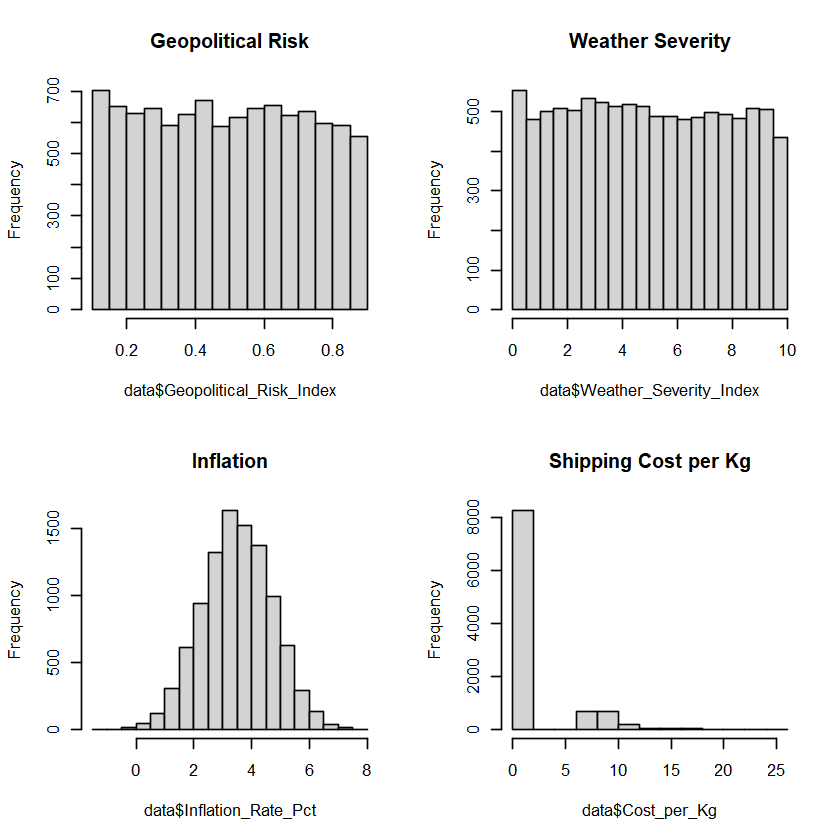

In [9]:
library(caret)
library(kknn)
library(rpart)
library(rpart.plot)
library(skimr)
library(psych)

data <- read.csv("C:/Users/iqure/Downloads/IT 190 Project - Imran Qureshi - Data.csv")
str(data)

data$Shipping_Cost_USD <- as.numeric(gsub("[^0-9.]", "", data$Shipping_Cost_USD))
data$Cost_per_Kg <- as.numeric(gsub("[^0-9.]", "", data$Cost..USD....per.Kg))
data$Order_Date <- as.Date(data$Order_Date, format = "%m/%d/%Y")
data$Delay_Days[data$Delay_Days < 0] <- 0

data$Delivery_Status <- factor(data$Delivery_Status)
data$Route_Type <- factor(data$Route_Type)
data$Product_Category <- factor(data$Product_Category)
data$Transportation_Mode <- factor(data$Transportation_Mode)

summary(data)
skim(data)
psych::describe(data)

par(mfrow=c(2,2))
hist(data$Geopolitical_Risk_Index, main = "Geopolitical Risk")
hist(data$Weather_Severity_Index, main = "Weather Severity")
hist(data$Inflation_Rate_Pct, main = "Inflation")
hist(data$Cost_per_Kg, main = "Shipping Cost per Kg")
dev.off()


The exploratory analysis showed that shipment delays were relatively infrequent compared to on-time deliveries, indicating a class imbalance within the dataset. Initial visualizations also suggested that operational variables such as route type and transportation-related factors displayed more noticeable variation than broader disruption indicators.

# k-Nearest Neighbors (kNN)

A k-nearest neighbors classification model was developed to predict whether a shipment would be delivered late or on time. Numerical variables were normalized prior to training to ensure equal weighting during distance calculations.


         Actual
Predicted Late On Time
  Late      33      27
  On Time  354    2586

Base kNN Accuracy: 0.873 


Confusion Matrix and Statistics

          Reference
Prediction Late On Time
   Late      33      27
   On Time  354    2586
                                          
               Accuracy : 0.873           
                 95% CI : (0.8606, 0.8847)
    No Information Rate : 0.871           
    P-Value [Acc > NIR] : 0.3846          
                                          
                  Kappa : 0.1171          
                                          
 Mcnemar's Test P-Value : <2e-16          
                                          
            Sensitivity : 0.08527         
            Specificity : 0.98967         
         Pos Pred Value : 0.55000         
         Neg Pred Value : 0.87959         
             Prevalence : 0.12900         
         Detection Rate : 0.01100         
   Detection Prevalence : 0.02000         
      Balanced Accuracy : 0.53747         
                                          
       'Positive' Class : Late            
               

k-Nearest Neighbors 

7000 samples
   7 predictor
   2 classes: 'Late', 'On Time' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 5600, 5601, 5600, 5600, 5599 
Resampling results across tuning parameters:

  kmax  Accuracy   Kappa     
   5    0.8709989  0.11158488
   7    0.8724276  0.05605349
   9    0.8732854  0.05627605
  11    0.8732854  0.05627605
  13    0.8732854  0.05627605
  15    0.8732854  0.05627605
  17    0.8732854  0.05627605
  19    0.8732854  0.05627605
  21    0.8732854  0.05627605
  23    0.8732854  0.05627605
  25    0.8732854  0.05627605

Tuning parameter 'distance' was held constant at a value of 2
Tuning
 parameter 'kernel' was held constant at a value of rectangular
Kappa was used to select the optimal model using the largest value.
The final values used for the model were kmax = 5, distance = 2 and kernel
 = rectangular.


,kmax,distance,kernel
,<dbl>,<dbl>,<fct>
1,5,2,rectangular


         Actual
Predicted Late On Time
  Late      33      27
  On Time  354    2586

Best kNN Accuracy: 0.873 


Confusion Matrix and Statistics

          Reference
Prediction Late On Time
   Late      33      27
   On Time  354    2586
                                          
               Accuracy : 0.873           
                 95% CI : (0.8606, 0.8847)
    No Information Rate : 0.871           
    P-Value [Acc > NIR] : 0.3846          
                                          
                  Kappa : 0.1171          
                                          
 Mcnemar's Test P-Value : <2e-16          
                                          
            Sensitivity : 0.08527         
            Specificity : 0.98967         
         Pos Pred Value : 0.55000         
         Neg Pred Value : 0.87959         
             Prevalence : 0.12900         
         Detection Rate : 0.01100         
   Detection Prevalence : 0.02000         
      Balanced Accuracy : 0.53747         
                                          
       'Positive' Class : Late            
               

Kappa 
0.1170745

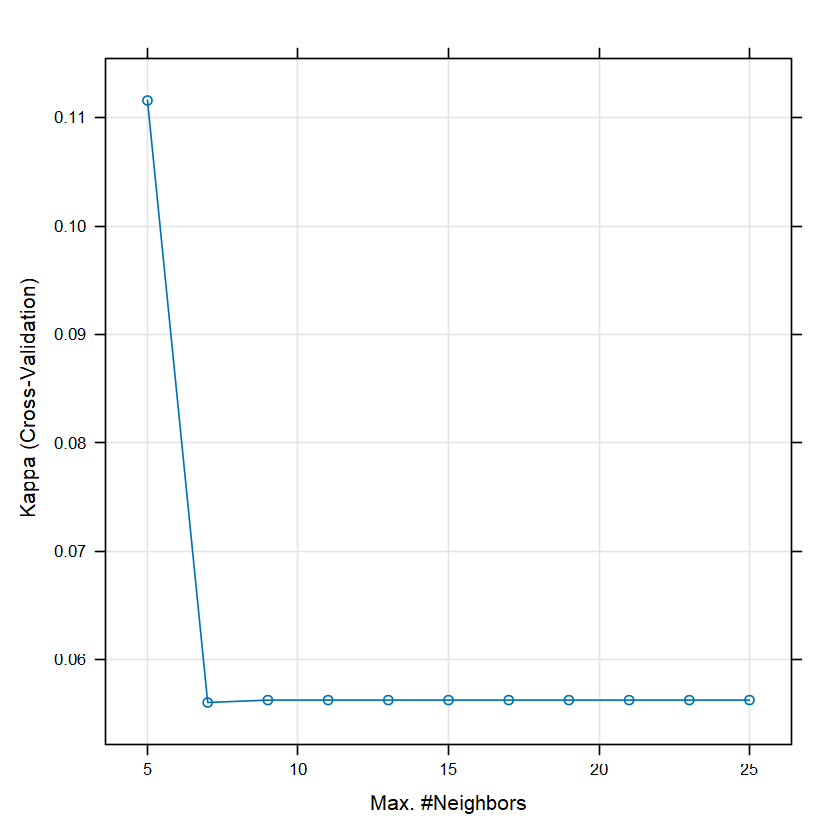

In [10]:
data$Cost_per_Kg_numeric <- data$Cost_per_Kg

data$Cost_per_Kg <- cut(
  data$Cost_per_Kg,
  breaks = c(0, 5, Inf),
  labels = c("Low","High"),
  include.lowest = TRUE
)

data$Cost_per_Kg <- factor(data$Cost_per_Kg, levels = c("Low", "High"))

data$Geopolitical_Risk_Index <- cut(
  data$Geopolitical_Risk_Index,
  breaks = c(0, 0.25, 0.5, 0.75, 1),
  labels = c("Low", "Moderate", "High", "Very High"),
  include.lowest = TRUE
)

data$Geopolitical_Risk_Index <- factor(data$Geopolitical_Risk_Index, levels = c("Low", "Moderate", "High", "Very High"))

set.seed(123)
train_indices <- createDataPartition(data$Delivery_Status, p = 0.7, list = FALSE)
train_data <- data[train_indices, ]
test_data  <- data[-train_indices, ]

train_data$Cost_per_Kg_numeric <- log(train_data$Cost_per_Kg_numeric)
test_data$Cost_per_Kg_numeric  <- log(test_data$Cost_per_Kg_numeric)

scaler <- preProcess(
  train_data[, c("Weather_Severity_Index",
                 "Inflation_Rate_Pct", "Cost_per_Kg_numeric")],
  method = c("center", "scale")
)

normalized_columns <- c("Weather_z",
                        "Inflation_z", "Cost_per_Kg_numeric_z")

train_data[normalized_columns] <- predict(
  scaler, train_data[, c("Weather_Severity_Index",
                         "Inflation_Rate_Pct", "Cost_per_Kg_numeric")]
)

test_data[normalized_columns] <- predict(
  scaler, test_data[, c("Weather_Severity_Index",
                        "Inflation_Rate_Pct", "Cost_per_Kg_numeric")]
)

k_neighbors <- 5
distance_metric  <- 2
kernel_type  <- "rectangular"

knn_base_model <- kknn(
  Delivery_Status ~ Weather_z + Geopolitical_Risk_Index +
    Inflation_z + Cost_per_Kg_numeric_z + Route_Type + Product_Category + Transportation_Mode,
  train    = train_data,
  test     = test_data,
  k        = k_neighbors,
  distance = distance_metric,
  kernel   = kernel_type
)

test_data$knn_base_pred <- fitted(knn_base_model)

table(Predicted = test_data$knn_base_pred, Actual = test_data$Delivery_Status)
knn_base_accuracy <- mean(test_data$knn_base_pred == test_data$Delivery_Status)
cat("Base kNN Accuracy:", knn_base_accuracy, "\n")

confusionMatrix(test_data$knn_base_pred, test_data$Delivery_Status, positive = "Late")

cv_control <- trainControl(method = "cv", number = 5)

knn_grid <- expand.grid(
  kmax     = seq(5, 25, by = 2),
  distance = c(2),
  kernel   = c("rectangular")
)

set.seed(42)
knn_cv_model <- train(
  Delivery_Status ~ Weather_z +
    Inflation_z + Cost_per_Kg_numeric_z + Geopolitical_Risk_Index +
    Route_Type + Product_Category + Transportation_Mode,
  data      = train_data,
  method    = "kknn",
  tuneGrid  = knn_grid,
  trControl = cv_control,
  metric    = "Kappa"
)

print(knn_cv_model)
plot(knn_cv_model)

best_knn_params <- knn_cv_model$bestTune
best_knn_params

knn_best_model <- kknn(
  Delivery_Status ~ Weather_z + Geopolitical_Risk_Index +
    Inflation_z + Cost_per_Kg_numeric_z +
    Route_Type + Product_Category + Transportation_Mode,
  train    = train_data,
  test     = test_data,
  k        = best_knn_params$kmax,
  distance = best_knn_params$distance,
  kernel   = as.character(best_knn_params$kernel)
)

test_data$knn_best_pred <- fitted(knn_best_model)

table(Predicted = test_data$knn_best_pred, Actual = test_data$Delivery_Status)
knn_best_accuracy <- mean(test_data$knn_best_pred == test_data$Delivery_Status)
cat("Best kNN Accuracy:", knn_best_accuracy, "\n")

confusionMatrix(test_data$knn_best_pred, test_data$Delivery_Status, positive = "Late")
confusionMatrix(test_data$knn_best_pred, test_data$Delivery_Status, positive = "Late")$overall["Kappa"]


The kNN classification model achieved approximately 87.3% overall accuracy after normalization and cross-validation. However, predictive performance for delayed shipments remained limited due to the imbalance between late and on-time deliveries within the dataset.

# Decision Tree Analysis

Decision trees were used to identify the strongest branching variables associated with shipment delay outcomes. This approach improved interpretability by visually displaying the sequence of conditions associated with delayed and on-time deliveries.


Call:
rpart(formula = Delivery_Status ~ Geopolitical_Risk_Index + Weather_Severity_Index + 
    Inflation_Rate_Pct + Cost_per_Kg + Route_Type + Product_Category + 
    Transportation_Mode, data = train_data, method = "class", 
    control = rpart.control(cp = 1e-04, split = "gini", minsplit = 20, 
        minbucket = 10, maxdepth = 3))
  n= 7000 

  CP nsplit rel error xerror xstd
1  0      0         1      0    0

Node number 1: 7000 observations
  predicted class=On Time  expected loss=0.129  P(node) =1
    class counts:   903  6097
   probabilities: 0.129 0.871 



         Actual
Predicted Late On Time
  Late       0       0
  On Time  387    2613

Base Decision Tree Accuracy: 0.871 


Confusion Matrix and Statistics

          Reference
Prediction Late On Time
   Late       0       0
   On Time  387    2613
                                          
               Accuracy : 0.871           
                 95% CI : (0.8585, 0.8828)
    No Information Rate : 0.871           
    P-Value [Acc > NIR] : 0.5135          
                                          
                  Kappa : 0               
                                          
 Mcnemar's Test P-Value : <2e-16          
                                          
            Sensitivity : 0.000           
            Specificity : 1.000           
         Pos Pred Value :   NaN           
         Neg Pred Value : 0.871           
             Prevalence : 0.129           
         Detection Rate : 0.000           
   Detection Prevalence : 0.000           
      Balanced Accuracy : 0.500           
                                          
       'Positive' Class : Late            
               

CART 

7000 samples
   7 predictor
   2 classes: 'Late', 'On Time' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 5600, 5601, 5600, 5600, 5599 
Resampling results across tuning parameters:

  cp     Accuracy   Kappa
  0.001  0.8710001  0    
  0.006  0.8710001  0    
  0.011  0.8710001  0    
  0.016  0.8710001  0    
  0.021  0.8710001  0    
  0.026  0.8710001  0    
  0.031  0.8710001  0    
  0.036  0.8710001  0    
  0.041  0.8710001  0    
  0.046  0.8710001  0    

Kappa was used to select the optimal model using the largest value.
The final value used for the model was cp = 0.046.


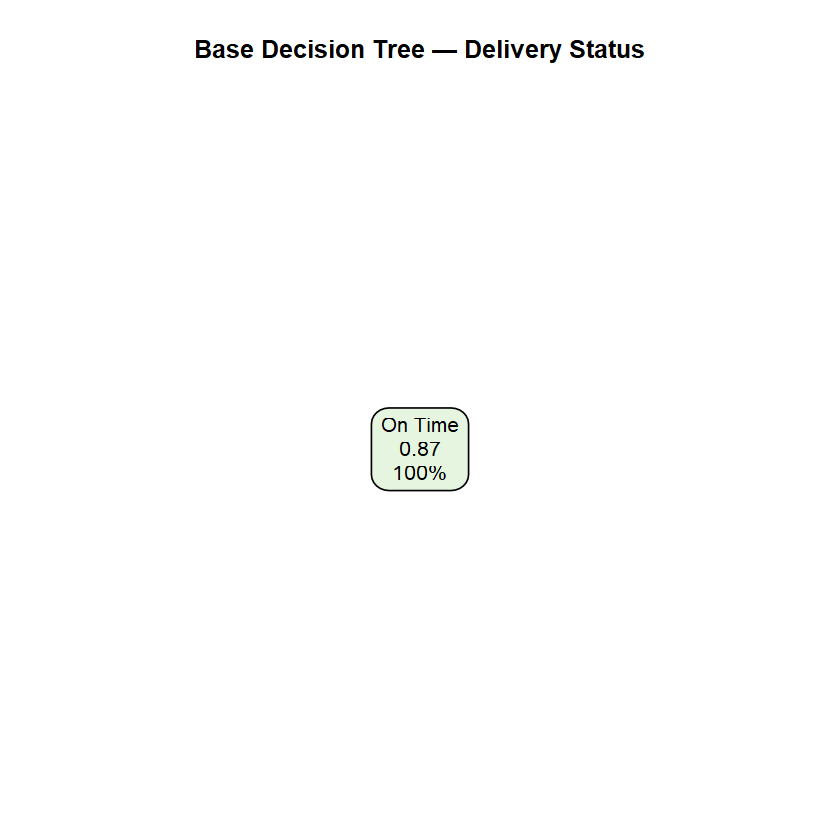

,cp
,<dbl>
10,0.046



Classification tree:
rpart(formula = Delivery_Status ~ Geopolitical_Risk_Index + Weather_Severity_Index + 
    Inflation_Rate_Pct + Cost_per_Kg + Route_Type + Product_Category + 
    Transportation_Mode, data = train_data, method = "class", 
    control = rpart.control(cp = 1e-04, split = "gini", minsplit = 10, 
        minbucket = 5, maxdepth = 4))

Variables actually used in tree construction:
[1] Geopolitical_Risk_Index Route_Type              Weather_Severity_Index 

Root node error: 903/7000 = 0.129

n= 7000 

          CP nsplit rel error xerror     xstd
1 0.00055371      0   1.00000 1.0000 0.031057
2 0.00055000      4   0.99779 1.0055 0.031131


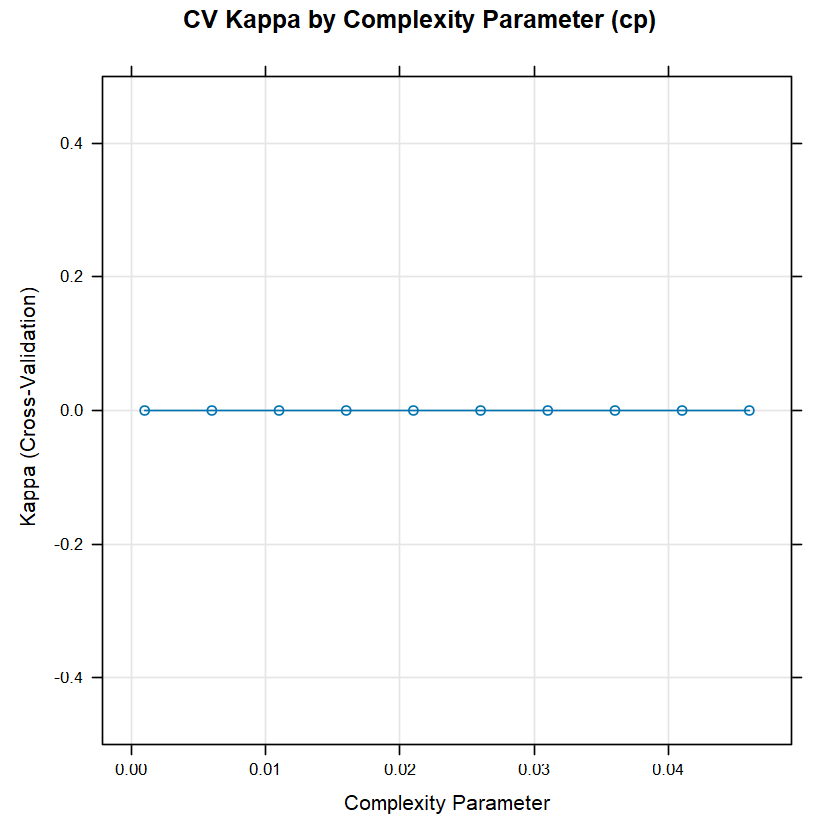

Call:
rpart(formula = Delivery_Status ~ Geopolitical_Risk_Index + Weather_Severity_Index + 
    Inflation_Rate_Pct + Cost_per_Kg + Route_Type + Product_Category + 
    Transportation_Mode, data = train_data, method = "class", 
    control = rpart.control(cp = 1e-04, split = "gini", minsplit = 10, 
        minbucket = 5, maxdepth = 4))
  n= 7000 

            CP nsplit rel error   xerror       xstd
1 0.0005537099      0 1.0000000 1.000000 0.03105741
2 0.0005500000      4 0.9977852 1.005537 0.03113050

Variable importance
             Route_Type Geopolitical_Risk_Index  Weather_Severity_Index 
                     60                      18                      12 
     Inflation_Rate_Pct        Product_Category 
                      5                       5 

Node number 1: 7000 observations,    complexity param=0.0005537099
  predicted class=On Time  expected loss=0.129  P(node) =1
    class counts:   903  6097
   probabilities: 0.129 0.871 
  left son=2 (2408 obs) right son=3 (4592 

         Actual
Predicted Late On Time
  Late       0       2
  On Time  387    2611

Best Decision Tree Accuracy: 0.8703333 


Confusion Matrix and Statistics

          Reference
Prediction Late On Time
   Late       0       2
   On Time  387    2611
                                          
               Accuracy : 0.8703          
                 95% CI : (0.8578, 0.8822)
    No Information Rate : 0.871           
    P-Value [Acc > NIR] : 0.5568          
                                          
                  Kappa : -0.0013         
                                          
 Mcnemar's Test P-Value : <2e-16          
                                          
            Sensitivity : 0.0000000       
            Specificity : 0.9992346       
         Pos Pred Value : 0.0000000       
         Neg Pred Value : 0.8709139       
             Prevalence : 0.1290000       
         Detection Rate : 0.0000000       
   Detection Prevalence : 0.0006667       
      Balanced Accuracy : 0.4996173       
                                          
       'Positive' Class : Late            
               

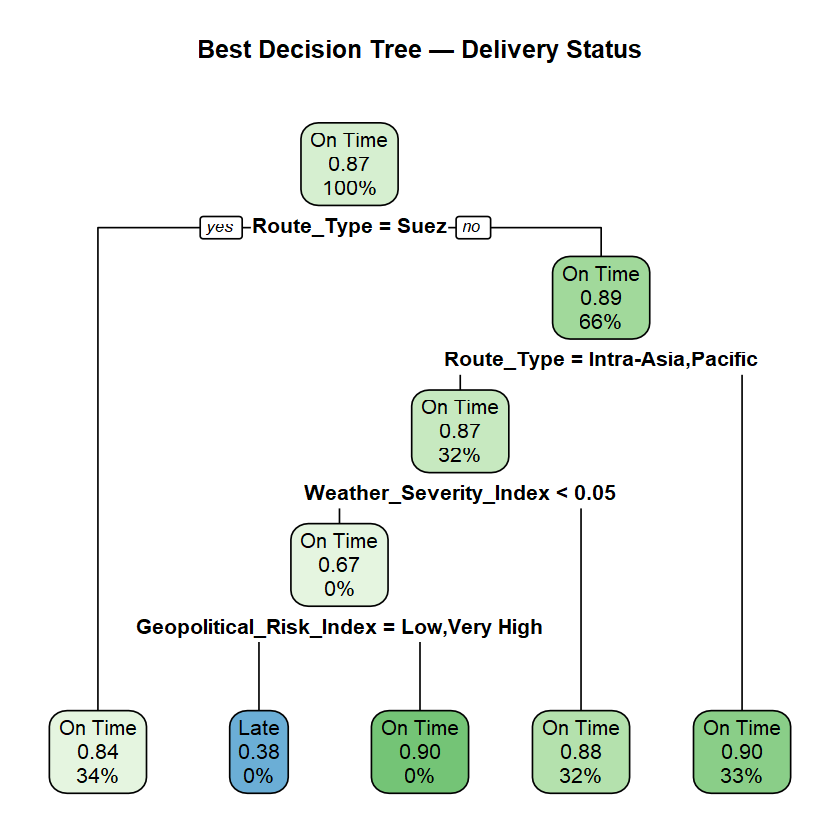

In [11]:
dt_base_model <- rpart(
  Delivery_Status ~ Geopolitical_Risk_Index + Weather_Severity_Index +
    Inflation_Rate_Pct + Cost_per_Kg +
    Route_Type + Product_Category + Transportation_Mode,
  data    = train_data,
  method  = "class",
  control = rpart.control(
    cp        = 0.0001,
    split     = "gini",
    minsplit  = 20,
    minbucket = 10,
    maxdepth  = 3
  )
)

rpart.plot(dt_base_model, main = "Base Decision Tree — Delivery Status")
summary(dt_base_model)

test_data$dt_base_pred <- predict(dt_base_model, test_data, type = "class")

table(Predicted = test_data$dt_base_pred, Actual = test_data$Delivery_Status)
dt_base_accuracy <- mean(test_data$dt_base_pred == test_data$Delivery_Status)
cat("Base Decision Tree Accuracy:", dt_base_accuracy, "\n")

confusionMatrix(test_data$dt_base_pred, test_data$Delivery_Status, positive = "Late")

dt_grid <- expand.grid(
  cp = seq(0.001, 0.050, by = 0.005)
)

set.seed(42)
dt_cv_model <- train(
  Delivery_Status ~ Geopolitical_Risk_Index + Weather_Severity_Index +
    Inflation_Rate_Pct + Cost_per_Kg +
    Route_Type + Product_Category + Transportation_Mode,
  data      = train_data,
  method    = "rpart",
  tuneGrid  = dt_grid,
  trControl = cv_control,
  control   = rpart.control(
    split     = "gini",
    minsplit  = 20,
    minbucket = 10,
    maxdepth  = 3
  ),
  metric    = "Kappa"
)

print(dt_cv_model)
plot(dt_cv_model, main = "CV Kappa by Complexity Parameter (cp)")

best_dt_params <- dt_cv_model$bestTune
best_dt_params

dt_best_model <- rpart(
  Delivery_Status ~ Geopolitical_Risk_Index + Weather_Severity_Index +
    Inflation_Rate_Pct + Cost_per_Kg +
    Route_Type + Product_Category + Transportation_Mode,
  data    = train_data,
  method  = "class",
  control = rpart.control(
    cp = .0001,
    split = "gini",
    minsplit = 10,
    minbucket = 5,
    maxdepth = 4)
)

dt_best_model <- prune(dt_best_model, cp = 0.00055)

printcp(dt_best_model)

rpart.plot(dt_best_model, main = "Best Decision Tree — Delivery Status")
summary(dt_best_model)

test_data$dt_best_pred <- predict(dt_best_model, test_data, type = "class")

table(Predicted = test_data$dt_best_pred, Actual = test_data$Delivery_Status)
dt_best_accuracy <- mean(test_data$dt_best_pred == test_data$Delivery_Status)
cat("Best Decision Tree Accuracy:", dt_best_accuracy, "\n")

confusionMatrix(test_data$dt_best_pred, test_data$Delivery_Status, positive = "Late")


The decision tree analysis identified route type as the strongest operational variable associated with shipment delay outcomes. Weather severity and geopolitical risk also contributed to branching decisions, although their predictive influence remained weaker than route-related operational factors.

# Model Summary Comparison

The final comparison evaluates how well the kNN and decision tree models classified whether shipments were late or on time.


In [12]:
knn_conf_mat  <- confusionMatrix(test_data$knn_best_pred, test_data$Delivery_Status, positive = "Late")
dt_base_conf_mat <- confusionMatrix(test_data$dt_base_pred,  test_data$Delivery_Status, positive = "Late")
dt_best_conf_mat <- confusionMatrix(test_data$dt_best_pred,  test_data$Delivery_Status, positive = "Late")

cat("\n=== Best kNN Model Performance ===\n")
cat("Accuracy:    ", knn_conf_mat$overall['Accuracy'],    "\n")
cat("Kappa:       ", knn_conf_mat$overall['Kappa'],       "\n")
cat("Sensitivity: ", knn_conf_mat$byClass['Sensitivity'], "\n")
cat("Specificity: ", knn_conf_mat$byClass['Specificity'], "\n")

cat("\n=== Base Decision Tree Performance ===\n")
cat("Accuracy:    ", dt_base_conf_mat$overall['Accuracy'],    "\n")
cat("Kappa:       ", dt_base_conf_mat$overall['Kappa'],       "\n")
cat("Sensitivity: ", dt_base_conf_mat$byClass['Sensitivity'], "\n")
cat("Specificity: ", dt_base_conf_mat$byClass['Specificity'], "\n")

cat("\n=== Best Decision Tree Performance ===\n")
cat("Accuracy:    ", dt_best_conf_mat$overall['Accuracy'],    "\n")
cat("Kappa:       ", dt_best_conf_mat$overall['Kappa'],       "\n")
cat("Sensitivity: ", dt_best_conf_mat$byClass['Sensitivity'], "\n")
cat("Specificity: ", dt_best_conf_mat$byClass['Specificity'], "\n")

model_comparison <- data.frame(
  Model       = c("Best kNN", "Base Decision Tree", "Best Decision Tree"),
  Accuracy    = c(knn_conf_mat$overall['Accuracy'],    dt_base_conf_mat$overall['Accuracy'],    dt_best_conf_mat$overall['Accuracy']),
  Kappa       = c(knn_conf_mat$overall['Kappa'],       dt_base_conf_mat$overall['Kappa'],       dt_best_conf_mat$overall['Kappa']),
  Sensitivity = c(knn_conf_mat$byClass['Sensitivity'], dt_base_conf_mat$byClass['Sensitivity'], dt_best_conf_mat$byClass['Sensitivity']),
  Specificity = c(knn_conf_mat$byClass['Specificity'], dt_base_conf_mat$byClass['Specificity'], dt_best_conf_mat$byClass['Specificity'])
)

print(model_comparison)



=== Best kNN Model Performance ===
Accuracy:     0.873 
Kappa:        0.1170745 
Sensitivity:  0.08527132 
Specificity:  0.989667 

=== Base Decision Tree Performance ===
Accuracy:     0.871 
Kappa:        0 
Sensitivity:  0 
Specificity:  1 

=== Best Decision Tree Performance ===
Accuracy:     0.8703333 
Kappa:        -0.00132824 
Sensitivity:  0 
Specificity:  0.9992346 
               Model  Accuracy       Kappa Sensitivity Specificity
1           Best kNN 0.8730000  0.11707453  0.08527132   0.9896670
2 Base Decision Tree 0.8710000  0.00000000  0.00000000   1.0000000
3 Best Decision Tree 0.8703333 -0.00132824  0.00000000   0.9992346


Overall, the classification models showed that operational transportation variables were more useful for predicting shipment delay outcomes than broader macro-disruption indicators alone. While overall accuracy remained relatively high, the models were more effective at identifying on-time shipments than delayed deliveries.

# Conclusion

- Geopolitical risk and weather severity showed relatively weak predictive influence on whether a shipment would ultimately be delayed or delivered on time.
- Route type emerged as one of the strongest operational predictors of shipment delay occurrence, with certain major shipping corridors producing noticeably higher concentrations of late deliveries.
- Transportation mode also contributed to delivery outcomes, indicating that shipment method influenced the probability of delays across the dataset.
- The decision tree classification model produced interpretable branching rules for distinguishing delayed versus on-time shipments.
- The kNN classification model improved after normalization and cross-validation, reinforcing that combinations of operational and disruption-related variables collectively influenced shipment delay outcomes.
- Overall, this part of the project showed that operational variables such as route type and transportation mode were more useful for classifying delay occurrence than broader geopolitical or weather-related indicators.
